In [3]:
# @title Initial Set Up

import ipywidgets as widgets
from IPython.display import display

def ask_mcq(qid, question, options, correct):
    radio = widgets.RadioButtons(
        options=options,
        layout=widgets.Layout(width='auto'),
        style={'description_width': '0px'}
    )

    radio.add_class("big-radio")

    btn = widgets.Button(description="Check answer", button_style='primary')
    out = widgets.Output()

    def check_answer(b):
        with out:
            out.clear_output()

            if radio.value == correct:
                print("✅ Correct!")
            else:
                print(f"❌ Incorrect, try again")

    btn.on_click(check_answer)

    display(widgets.HTML(f"<b style='font-size:24px'>{question}</b>"))
    display(radio, btn, out)

    display(widgets.HTML("""
    <style>
    .big-radio label {
        font-size: 20px !important;
    }
    </style>
    """))



### The Fourier Transform
The classical Fourier Transform is used to convert a signal in the time domain into a signal in the frequency domain. It is one of the most important discoveries of modern engineering and has applications in anything related to sound, electronic signals, data compression, and medical imaging. Because of how broad and utilized the Fourier Transform is there are a few different 'versions' of it for different applications. In this notebook we will focus on the Discete Fourier Transform (DFT) and use it as a stepping stone into the Quantum Fourier Transform (QFT).

We will go over the DFT fisrt as it is the most intuitive and can help get a feel for what is going on but then move on to the FFT which the actual algorithm computer scientists use to compute the transform.

The DFT is heavily based in mathmatical formulas which can be daunting and hard to understand but are neccisary to get the full picture of what the DFT does. For this notebook we will provide the equations and explain how they work but put more of a focus on how the DFT works conceptually (ie what its input is, what the transform does, and what the output is).

Say you are given a periodic signal, we can think of it as just a sum of a bunch of sin waves, the goal of the DFT is to pick apart the signal and find the frequencies of each of those waves. Then you can perform whatever calculations or analysis on those frequencies that you would like. Then you can perform something called the Inverse Fourier Transform which will turn those frequencies back into a signal in the time domain.




Now we will look at the mathmatical formula for the DFT
The DFT is commonly defined as:

$X_k = \sum_{n=0}^{N-1} x_n e^{-2\pi i kn/N}$

Where $x_n$ is the orignal input signal, $n$ which signal is currently being looked at, $N$ the total number of signals the input is being decomposed to (larger $N$ means more frequencies and less seperation between them), $k$ the value of the frequency (the larger $k$ is the higher the frequency of the wave), and $X_k$ which we call the Fourier Coeffient of that frequency (holds the amplitdue and phase associated with the frequency).

The Inverse Fourier Transform is very similar to the DFT, it is defined as:


$x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{2\pi i kn/N}$

where $X_k$ are the frequency-domain coefficients and  are the time-domain signal values.

All that has changed is the places of $X_k$ and $x_n$ have swapped and the sign of $e^{-2\pi i kn/N}$ has swapped.

Applying the DFT followed by the IDFT recovers the original signal. This makes the DFT/IDFT pair useful for signal processing workflows: transform to frequency domain, apply filters or analysis, then transform back to get the modified signal.

Now we will get into the formal mathmatical definition. To make the formulas more compact we will define $\omega_N$ as

$\omega_N = e^{2\pi i/N} = \cos\left(\frac{2\pi}{N}\right) + i\sin\left(\frac{2\pi}{N}\right)$

The DFt can be expressed as a matrix-vector operation:

$$\mathbf{X} = \mathbf{F} \mathbf{x}$$

where $\mathbf{F}$ is the DFT matrix and $\mathbf{x}$ is the input signal vector.

DFT Matrix

$$\mathbf{F} = \frac{1}{\sqrt{N}} \begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega_N & \omega_N^2 & \cdots & \omega_N^{N-1} \\
1 & \omega_N^2 & \omega_N^4 & \cdots & \omega_N^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega_N^{N-1} & \omega_N^{2(N-1)} & \cdots & \omega_N^{(N-1)^2}
\end{pmatrix}$$

Input and Output Vectors

$$\mathbf{x} = \begin{pmatrix} x_0 \\ x_1 \\ x_2 \\ \vdots \\ x_{N-1} \end{pmatrix}, \quad \mathbf{X} = \begin{pmatrix} X_0 \\ X_1 \\ X_2 \\ \vdots \\ X_{N-1} \end{pmatrix}$$

Element-wise Formula

$$X_k = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x_n \omega_N^{-nk}$$

where $\omega_N = e^{2\pi i/N}$ and $k \in \{0, 1, \ldots, N-1\}$.

### Fast Fourier Transform (FFT)
When computers actually calculate the DFT they use a special idea called the Fast Fourier Transform (FFT). The FFT makes use of some special mathmatical ideas.

Firstly, it uses the idea that functions can be split up into even and odd parts. Specifically it splits up the even and odd $x_n$ terms into ($x_0, x_2, x_4 ...$) and ($x_1, x_3, x_5 ... $). This also means you can rewrite the odd terms to be the "twiddle factor" times the even terms.

The twiddle factor is definded to be $\omega_N = e^{-2\pi i/N}$ and it can be though of as a rotation in the complex plane.

We can write the FFT in summation notation as the following

$X_k = \sum_{m=0}^{N/2-1} x_{2m} e^{-2\pi i k(2m)/N} + e^{-2\pi i k/N} \sum_{m=0}^{N/2-1} x_{2m+1} e^{-2\pi i k(2m)/N}$




$\omega_N^{k+N/2} = -\omega_N^k$. <- rewrite this to make more sense

This means the DFT outputs repeat with a sign flip at the halfway point. Therefore, we only need to compute half the frequencies and can derive the rest for free by using a '-' sign instead of a '+' sign.

By combining these two ideas—dividing the problem recursively and exploiting the periodicity—we can build up the full DFT from many small pieces using divide and conquer recursion as shown below.

The Butterfly Operation (Divide and Conquer)

After computing smaller DFTs, we recombine using:

$$X_k = E_k + W_k O_k$$

$$X_{k+N/2} = E_k - W_k O_k$$

where:
- $E_k$ = even part
- $O_k$ = odd part  
- $W_k = e^{-2\pi i k/N}$ (twiddle factor)

FFT Algorithm Pseudocode


$$\begin{align}
&\quad N \gets \text{length}(x) \\
&\quad \text{if } N = 1 \text{ then} \\
&\quad \quad \text{return } x \\
&\quad \text{even} \gets \text{FFT}(x[0, 2, 4, \ldots]) \\
&\quad \text{odd} \gets \text{FFT}(x[1, 3, 5, \ldots]) \\
&\quad X \gets [0, 0, \ldots, 0] \quad \text{(length } N\text{)} \\
&\quad \text{for } k = 0 \text{ to } N/2 - 1 \text{ do} \\
&\quad \quad W_k \gets e^{-2\pi i k/N} \\
&\quad \quad X[k] \gets \text{even}[k] + W_k \cdot \text{odd}[k] \\
&\quad \quad X[k + N/2] \gets \text{even}[k] - W_k \cdot \text{odd}[k] \\
&\quad \text{end for} \\
&\quad \text{return } X
\end{align}$$

Key Steps

1. **Base case**: If input length is 1, return it immediately
2. **Divide**: Split input into even and odd indexed elements
3. **Conquer**: Recursively compute FFT of each half
4. **Combine**: Use butterfly operations to recombine results

Each time it calls "FFT" it is essentially computing the DFT on a smaller part of the signal, then combining them all back up together. The use of the FFT changes the runtime from $O(N^2)$ to $O(N \log N)$. An interactive visualisation of how the FFT transforms a signal into its frequencies is shown below.

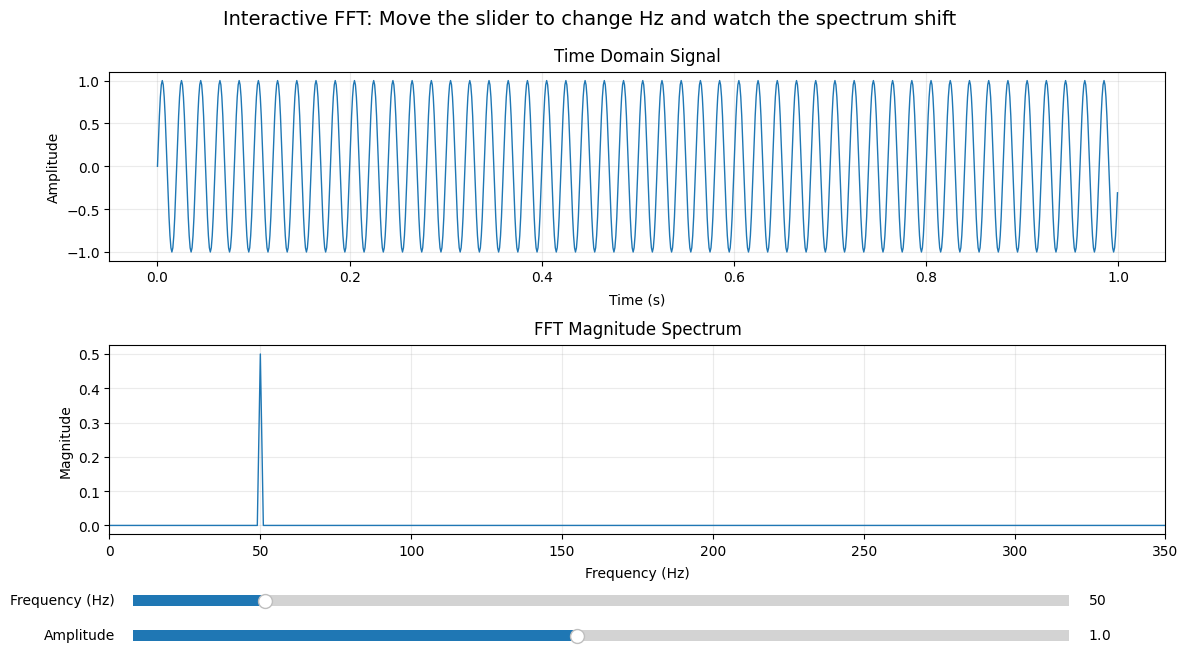

In [7]:
# @title Interactive FFT demo with a slider to change frequency (Hz) live

""" Use Zoom/Pan tool to zoom into FFT plot for better visibility """

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider


def compute_fft_mag(x, fs):
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    mag = np.abs(X) / len(x)
    return freqs, mag


def make_sine(t, hz, amp):
    return amp * np.sin(2 * np.pi * hz * t)


def main():
    # Sampling setup
    fs = 1000          # samples/sec
    duration = 1.0     # seconds
    t = np.arange(0, duration, 1.0 / fs)

    # Initial params
    hz0 = 50.0
    amp0 = 1.0

    x = make_sine(t, hz0, amp0)
    freqs, mag = compute_fft_mag(x, fs)

    # Bigger figure + better spacing
    fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(12, 7))

    # Reserve enough bottom for 2 sliders, plus extra top room for suptitle
    fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.22, hspace=0.45)

    # Time-domain line
    (line_time,) = ax_time.plot(t, x, lw=1)
    ax_time.set_title("Time Domain Signal", pad=8)
    ax_time.set_xlabel("Time (s)", labelpad=6)
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True, alpha=0.25)

    # Frequency-domain line
    (line_fft,) = ax_fft.plot(freqs, mag, lw=1)
    ax_fft.set_title("FFT Magnitude Spectrum", pad=8)
    ax_fft.set_xlabel("Frequency (Hz)", labelpad=6)
    ax_fft.set_ylabel("Magnitude")

    ax_fft.set_xlim(0, 350) # limit x-axis to 250 Hz for better visibility
    ax_fft.grid(True, alpha=0.25)

    # Slider axes (moved slightly lower + thinner so they fit cleanly)
    left = 0.12
    width = 0.78
    ax_hz = fig.add_axes([left, 0.11, width, 0.03])
    ax_amp = fig.add_axes([left, 0.06, width, 0.03])

    # Sliders
    # change valmax and valstep for finer control
    hz_slider = Slider(ax=ax_hz, label="Frequency (Hz)", valmin=1, valmax=350, valinit=hz0, valstep=1)
    amp_slider = Slider(ax=ax_amp, label="Amplitude", valmin=0.1, valmax=2.0, valinit=amp0, valstep=0.1)

    # Update function called whenever slider moves
    def update(_):
        hz = hz_slider.val
        amp = amp_slider.val

        x_new = make_sine(t, hz, amp)
        freqs_new, mag_new = compute_fft_mag(x_new, fs)

        line_time.set_ydata(x_new)
        line_fft.set_ydata(mag_new)

        # Keep y-limits reasonable as amplitude changes
        ax_time.set_ylim(-2.2, 2.2)
        ax_fft.set_ylim(0, max(0.001, float(mag_new.max()) * 1.15))

        fig.canvas.draw_idle()

    hz_slider.on_changed(update)
    amp_slider.on_changed(update)

    fig.suptitle(
        "Interactive FFT: Move the slider to change Hz and watch the spectrum shift",
        fontsize=14,
        y=0.97,  # lift the suptitle a bit
    )

    plt.show()


if __name__ == "__main__":
    main()

Another way we can think of what the DFT (or FFT) is doing is its mapping something from the time domain into the frequency domain. This idea of mapping something from one domain, and changing it into another domain is the same thing that the QFT does. In fact, the QFT and DFT are so similar mathmatically that the matrix representation for them both are the same execpt that the QFT transforms basis state vectors not signals.

The Quantum Fourier Transform (QFT) is the quantum version of the classical Discrete Fourier Transform (DFT). It takes a quantum state expressed in the computational basis and transforms it into a new basis that reveals frequency-like information through quantum phases.

Instead of operating on numbers, the QFT operates on probability amplitudes of a quantum state. It uses quantum phenomena like superposition and interference to perform the transformation extremely efficiently.

For an n-qubit system, the QFT can be implemented using only Hadamard gates, controlled phase rotations, and swap gates. While the QFT is faster than DFT it only works on the amplitudes of the basis states which cannot be directly measured on a real quantum machine so it is not a full replacement of the DFT.

In [5]:
# @title Question 1
ask_mcq(
    "q1",
    "What does the DFT do?",
    ["Compresses data by removing noise", "Converts a discrete signal from time domain to frequency domain", "Solves linear systems of equations","Randomizes signal phases"],
    correct="Converts a discrete signal from time domain to frequency domain"
)



HTML(value="<b style='font-size:24px'>What does the DFT do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Compresses data by removing n…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [6]:
# @title Question 2
ask_mcq(
    "q2",
    "What mathematical idea does FFT take advantage of?",
    ["Matrix inversion", "Random sampling", "Even function symmetry and divide-and-conquer", "Numerical integration"],
    correct="Even function symmetry and divide-and-conquer"
)




HTML(value="<b style='font-size:24px'>What mathematical idea does FFT take advantage of?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Matrix inversion', 'Random sa…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [7]:
# @title Question 3
ask_mcq(
    "q3",
    "Why do we use FFT over DFT?",
    ["It uses less memory only", "It provides exact symbolic answers", "It is computationally faster","It works only for analog signals"],
    correct="It is computationally faster"
)



HTML(value="<b style='font-size:24px'>Why do we use FFT over DFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('It uses less memory only', 'I…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [8]:
# @title Question 4
ask_mcq(
    "q4",
    "What is the runtime of DFT and of FFT?",
    ["DFT: O(n), FFT: O(nlog⁡n)", "DFT: O(n^2), FFT: O(nlog⁡n)", "DFT: O(log⁡n), FFT: O(n^2)","DFT: O(nlog⁡n), FFT: O(n^2)"],
    correct="DFT: O(n^2), FFT: O(nlog⁡n)"
)



HTML(value="<b style='font-size:24px'>What is the runtime of DFT and of FFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('DFT: O(n), FFT: O(nlog\u2061n…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [9]:
# @title Question 5
ask_mcq(
    "q5",
    "What does the Inverse Fourier Transform do?",
    ["Removes high frequencies", "Converts frequency-domain data back to the original time-domain signal", "Squares all amplitudes","Encrypts the signal"],
    correct="Converts frequency-domain data back to the original time-domain signal"
)



HTML(value="<b style='font-size:24px'>What does the Inverse Fourier Transform do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Removes high frequencies', 'C…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

## The Quantum Fourier Transform

The Quantum Fourier Transform (QFT) is a quantum algorithm that performs a Fourier transform on quantum amplitudes.
Definition

The QFT acts on an $n$-qubit quantum state and is defined as:

$$\text{QFT} |{x}⟩ = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk/N} |{k}⟩$$

where $N = 2^n$ and $x \in \{0, 1, \ldots, N-1\}$.

 Matrix Form

The QFT can be represented as an $N \times N$ unitary matrix:

$$\text{QFT} = \frac{1}{\sqrt{N}} \begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega & \omega^2 & \cdots & \omega^{N-1} \\
1 & \omega^2 & \omega^4 & \cdots & \omega^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega^{N-1} & \omega^{2(N-1)} & \cdots & \omega^{(N-1)^2}
\end{pmatrix}$$

where $\omega = e^{2\pi i/N}$ is a primitive $N$-th root of unity.

Key Properties

- **Unitary**: $\text{QFT}^\dagger \text{QFT} = I$
- **Reversible**: The inverse QFT is given by $\text{QFT}^{-1} = \text{QFT}^\dagger$
- **Complexity**: Classical: $O(N^2)$, Quantum: $O(n^2)$ where $N = 2^n$



Quantum Fourier Transform Applications
While the QFT on its own isn't really that helpful, it does play a very important role in other quantum algorithms, most notiably Shor's factoring algorithm where instead of classical algorithms having $O(2^{n/2})$ order runtime Shor's has $O(n^3)$. While this moduel is on the QFT and not Shor's algorithm the QFT plays a key role in the expoental speed up that Shor's algorithm provides. Other common applications of the QFT include phase estimation and order finding.

Gate-Level Implementation

The QFT can be efficiently implemented using only three types of quantum gates:

1. **Hadamard Gates**

For each qubit $j$, apply a Hadamard gate:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

This creates a superposition of the computational basis states.

2. **Controlled Phase Rotations**

After the Hadamard on qubit $j$, apply controlled phase gates $\text{CP}(\theta)$ from qubits $k > j$ to qubit $j$:

$$\text{CP}(\theta) = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & e^{i\theta} \end{pmatrix}$$

The angle is: $\theta = \frac{2\pi}{2^{k-j}}$

These phase gates create the interference patterns needed to encode the frequency information into the phases of the quantum state.

3. **SWAP Gates**

At the end, apply SWAP gates to reverse the order of the qubits:

$$\text{SWAP} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$


This gate sequence transforms the quantum state from the computational basis to the frequency basis, with the QFT matrix encoded in the controlled phases and interference patterns.

In [11]:
# @title Initial Imports
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q pylatexenc


import qiskit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
import numpy as np
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


First we will create the inital state of the system in the computational basis.

In [12]:
qubits = "100"
n = len(qubits)
qubits = qubits[::-1]
cir = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        cir.x(i)


### Circuit Level Algorithm Defintion
The algorithm works by applying a set of gates to each qubit. The following is the step-by-step outline:

1. For each qubit $i$ (from 0 to $n-1$):
   - Apply a Hadamard gate $H$ to qubit $i$
   - For each qubit $k$ where $k > i$ (higher-indexed qubits):
     - Apply a controlled phase gate $\text{CP}(\theta)$ from qubit $k$ (control) to qubit $i$ (target)
     - The phase angle is: $\theta = \frac{2\pi}{2^{k-i}}$

2. After processing all qubits, apply SWAP gates to reverse the qubit order:
   - Swap qubit $i$ with qubit $n-1-i$ for $i = 0$ to $\lfloor n/2 \rfloor - 1$

This creates the quantum superposition with encoded frequency information through phase interference.

In [13]:
def QFT(circuit, n):

    for i in range(n): #loop over each qubit
        circuit.h(i) #First apply a H gate to the current qubit

        for k in range(i + 1, n): #loop over each qubit where k>i
            N = np.pi / (2 ** (k - i)) #calculate the angle for the controlled phase gate
            circuit.cp(N, k, i) #apply a controlled phase gate on all other qbits

    for i in range(n // 2): #swap at end
        circuit.swap(i, n - i - 1)


Print the circuit to verify correctness

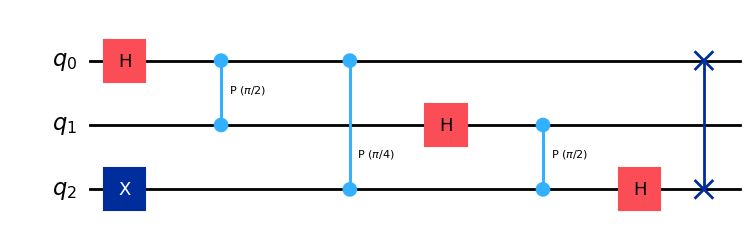

In [14]:
QFT(cir, n)
cir.draw(output="mpl")


#### The Inverse Quantum Fourier Transform (IQFT)

The Inverse Quantum Fourier Transform (IQFT) reverses the operation of the QFT, transforming from the frequency domain back to the computational basis. It is the Hermitian adjoint (conjugate transpose) of the QFT.

*Definition*

$$\text{IQFT} = \text{QFT}^{\dagger}$$

The IQFT acts on an $n$-qubit quantum state as:

$$\text{IQFT} |{k}⟩ = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} e^{-2\pi i xk/N} |{x}⟩$$

**Key Property: Reversibility**

Just like with the Inverse Fourier Transform, if you apply the IQFT to a system after you have applied the QFT to it you get back the original state.

$$\text{IQFT}(\text{QFT}(|{\psi})⟩) = |{\psi}⟩$$

This makes the QFT/IQFT pair a useful tool for quantum algorithms - you can transform to the frequency domain, perform operations, and transform back.

### Implementation

The IQFT is implemented by:
1. Reversing the order of gates from the QFT
2. Using the **negative** of the phase angles in the controlled phase gates
3. The algorithm structure mirrors the QFT but with conjugated operations

Lets also define the inverse QFT
It should be the case that if we apply the QFT then the IQFT we get the orignal state back

In [25]:
def IQFT(circuit, n):
    #YOUR TURN: implement the inverse QFT by reversing the steps of the QFT and negating the angles for the controlled phase gates
    ### TODO implement the inverse QFT
  pass


In [30]:
# @title Test cases to verify IQFT implementation


# Test 1: QFT followed by IQFT should recover the original state
print("Test 1: QFT → IQFT Recovery")
print("=" * 50)

# Get the statevector after QFT+IQFT
test_circuit = qiskit.QuantumCircuit(n)
for i in range(n):
    if qubits[i] == "1":
        test_circuit.x(i)

# Apply QFT then IQFT
QFT(test_circuit, n)
IQFT(test_circuit, n)

# Get the result
test_circuit.save_statevector()
sim = AerSimulator(method="statevector")
result = sim.run(test_circuit).result()
final_state = result.get_statevector()

# Calculate probabilities
final_probs = np.abs(final_state) ** 2

# Original state index (from binary string)
original_index = int(qubits[::-1], 2)

print(f"Original qubit state: {qubits}")
print(f"Original state index: |{original_index}⟩")
print(f"Probability of recovering original state: {final_probs[original_index]:.6f}")
print(f"Max probability deviation from 1.0: {1.0 - final_probs[original_index]:.2e}")

# Test passes if probability is very close to 1
test1_pass = final_probs[original_index] > 0.999
print(f"✓ Test 1 PASSED" if test1_pass else "✗ Test 1 FAILED")

print("\n" + "=" * 50)
print("Test 2: All other states should have near-zero probability")
print("=" * 50)

# Check that other basis states have negligible probability
other_state_probs = [final_probs[i] for i in range(len(final_probs)) if i != original_index]
max_other_prob = max(other_state_probs) if other_state_probs else 0

print(f"Maximum probability of other basis states: {max_other_prob:.2e}")

test2_pass = max_other_prob < 0.01
print(f"✓ Test 2 PASSED" if test2_pass else "✗ Test 2 FAILED")

print("\n" + "=" * 50)
print("Test 3: Verify IQFT is Hermitian adjoint of QFT")
print("=" * 50)

# The QFT followed by IQFT should produce identity (within numerical precision)
test_circuit2 = qiskit.QuantumCircuit(n)
test_circuit2.x(1)  # Put system in |010⟩ state

QFT(test_circuit2, n)
IQFT(test_circuit2, n)

test_circuit2.save_statevector()
result2 = sim.run(test_circuit2).result()
final_state2 = result2.get_statevector()
probs2 = np.abs(final_state2) ** 2

print(f"Starting state: |010⟩ (index 2)")
print(f"Probability of recovering |010⟩: {probs2[2]:.6f}")

test3_pass = probs2[2] > 0.999
print(f"✓ Test 3 PASSED" if test3_pass else "✗ Test 3 FAILED")

print("\n" + "=" * 50)
print(f"Overall: {'ALL TESTS PASSED ✓' if (test1_pass and test2_pass and test3_pass) else 'SOME TESTS FAILED ✗'}")
print("=" * 50)




Test 1: QFT → IQFT Recovery
Original qubit state: 001
Original state index: |4⟩
Probability of recovering original state: 1.000000
Max probability deviation from 1.0: 2.22e-16
✓ Test 1 PASSED

Test 2: All other states should have near-zero probability
Maximum probability of other basis states: 1.88e-32
✓ Test 2 PASSED

Test 3: Verify IQFT is Hermitian adjoint of QFT
Starting state: |010⟩ (index 2)
Probability of recovering |010⟩: 1.000000
✓ Test 3 PASSED

Overall: ALL TESTS PASSED ✓


Create the circuit again this time to run QFT then IQFT to make sure we get the original state back.

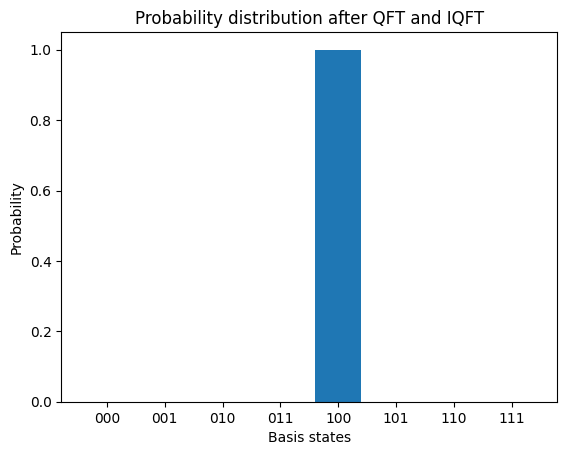

In [31]:
qubits = "100"
n = len(qubits)
qubits = qubits[::-1]
cir = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        cir.x(i)
QFT(cir, n)
IQFT(cir, n)
cir.draw(output="mpl")
# plot the current probabilites
cir.save_statevector()
sim = AerSimulator(method="statevector")
result = sim.run(cir).result()
state = result.get_statevector()
labels = [format(i, f'0{n}b') for i in range(2**n)]
probs = np.abs(state) ** 2

plt.bar(labels, probs)
plt.xlabel("Basis states")
plt.ylabel("Probability")
plt.title("Probability distribution after QFT and IQFT")
plt.show()
None

The circuits look correct and we get the target state back with what appears to be 100% probability

In [15]:
# @title Question 6
ask_mcq(
    "q6",
    "What are some practical applications of QFT?",
    ["Image compression ", "Sorting classical array", "Period finding and phase estimation in quantum algorithms", "Classical database indexing"],
    correct="Period finding and phase estimation in quantum algorithms"
)




HTML(value="<b style='font-size:24px'>What are some practical applications of QFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Image compression ', 'Sorting…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [32]:
# @title Question 7
ask_mcq(
    "q7",
    "What three gates does the QFT primarily utilize?",
    ["Pauli-X, Pauli-Y, Pauli-Z", "CNOT, Toffoli, SWAP", "Hadamard, controlled phase rotations, SWAP", "Measurement, Pauli-X, reset"],
    correct="Hadamard, controlled phase rotations, SWAP"
)




HTML(value="<b style='font-size:24px'>What three gates does the QFT primarily utilize?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Pauli-X, Pauli-Y, Pauli-Z', '…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [17]:
# @title Question 8
ask_mcq(
    "q8",
    "What does the QFT do?",
    ["Measures all qubits", "Performs classical convolution", "Maps computational basis states into phase-encoded superpositions (quantum frequency domain)", "Copies quantum states"],
    correct="Maps computational basis states into phase-encoded superpositions (quantum frequency domain)"
)





HTML(value="<b style='font-size:24px'>What does the QFT do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Measures all qubits', 'Perfor…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [19]:
# @title Question 9
ask_mcq(
    "q9",
    "Why is QFT not a complete replacement for DFT?",
    ["QFT is slower than FFT in all cases", "QFT requires analog hardware", "QFT outputs amplitudes that cannot all be measured simultaneously", "QFT cannot compute phases"],
    correct="QFT outputs amplitudes that cannot all be measured simultaneously"
)




HTML(value="<b style='font-size:24px'>Why is QFT not a complete replacement for DFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('QFT is slower than FFT in all…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [18]:
# @title Question 10
ask_mcq(
    "q10",
    "Measuring a quantum state after QFT typically gives:",
    "Checking every item one by one is called:",
    ["All Fourier coefficients", "Half the coefficients", "One sampled outcome", "No information"],
    correct="One sampled outcome"
)



HTML(value="<b style='font-size:24px'>Checking every item one by one is called:</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('All Fourier coefficients', 'H…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …